# starfold quickstartThis notebook runs `starfold`'s full methodology on a topologicallyinteresting synthetic dataset: **a closed chain of eight Hopf-linkedtori in 3D space**. Adjacent tori interlock through their centralholes; non-adjacent tori do not. It's the kind of dataset that willtrip up naive clustering -- but it exposes what UMAP does to atopologically non-trivial point cloud, and what HDBSCAN makes of theresult.The generator lives in `../examples/torus_chain.py`. You can edit itto explore different `n_links`, radii, or tube thicknesses.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# The generator is bundled as an example, not shipped inside the package.
sys.path.insert(0, str(Path.cwd().parent / 'examples'))
from torus_chain import make_torus_chain, linking_matrix

import starfold as sf

## 1. Build the datasetEight tori, 1,200 points each, sampled uniformly from the 3D body ofeach torus. Even-indexed tori sit vertically; odd-indexed ones sithorizontally. The radii are chosen so that the two crossings of anadjacent ring through a torus disk split one-inside / one-outside,which is exactly the Hopf-link geometry.

In [2]:
X, y_true = make_torus_chain(
    n_links=8,
    points_per_link=1200,
    big_radius=4.0,
    major_even=2.0,
    major_odd=2.5,
    minor_radius=0.15,
    solid=True,
    noise_std=0.02,
)
X.shape, np.unique(y_true)

((9600, 3), array([0, 1, 2, 3, 4, 5, 6, 7]))

### Visual checkTwo views of the chain: a default 3D perspective, and a near-overheadview that makes the alternating vertical / horizontal orientationobvious.

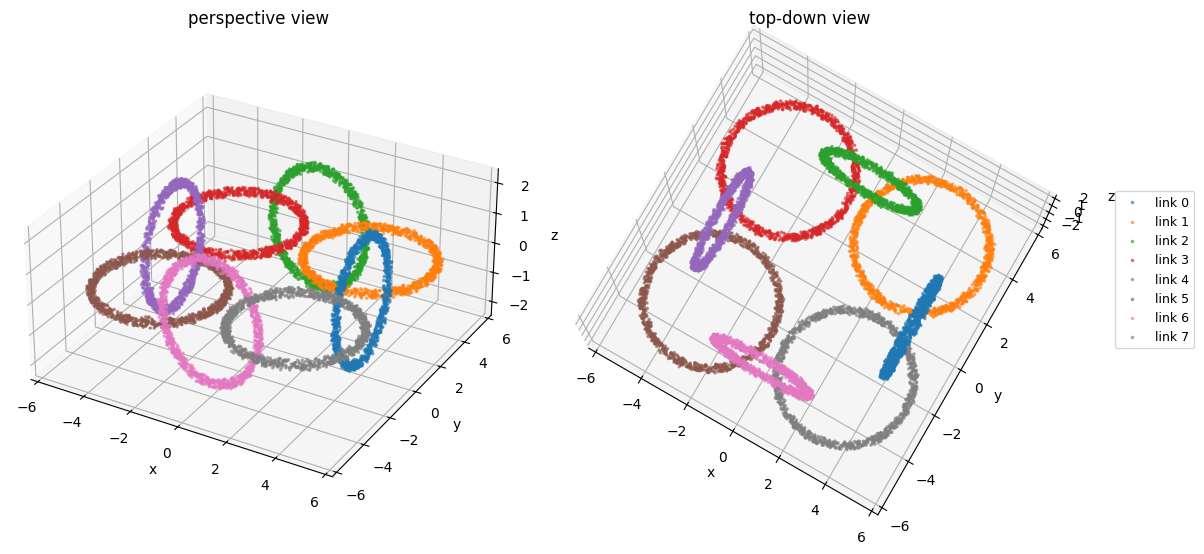

In [3]:
def _scatter_chain(ax, X, labels, title):
    cmap = plt.get_cmap('tab10')
    for k in range(8):
        mask = labels == k
        ax.scatter(
            X[mask, 0], X[mask, 1], X[mask, 2],
            s=2.5, color=cmap(k), alpha=0.55, label=f'link {k}',
        )
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.set_title(title)
    ax.set_box_aspect((1, 1, 0.5))

fig = plt.figure(figsize=(12, 5.5))
ax1 = fig.add_subplot(121, projection='3d')
_scatter_chain(ax1, X, y_true, 'perspective view')
ax2 = fig.add_subplot(122, projection='3d')
ax2.view_init(elev=80, azim=-60)
_scatter_chain(ax2, X, y_true, 'top-down view')
fig.legend(*ax1.get_legend_handles_labels(),
           loc='center right', bbox_to_anchor=(1.02, 0.5), fontsize=9)
plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.show()

### Topology check: the linking-number matrixFor a closed chain, the $(i, j)$ linking number should be $\pm 1$ iff$|i - j| \equiv 1 \pmod N$, and zero elsewhere. That's a tridiagonalmatrix plus the two corners -- our chain is a genuine closed loop.

In [4]:
L = linking_matrix()
print('linking matrix:')
print(L)
print(f'\ntotal linked pairs = {int((L != 0).sum()) // 2}  (expected {L.shape[0]} for a closed chain)')

linking matrix:
[[ 0 -1  0  0  0  0  0  1]
 [-1  0  1  0  0  0  0  0]
 [ 0  1  0 -1  0  0  0  0]
 [ 0  0 -1  0  1  0  0  0]
 [ 0  0  0  1  0 -1  0  0]
 [ 0  0  0  0 -1  0  1  0]
 [ 0  0  0  0  0  1  0 -1]
 [ 1  0  0  0  0  0 -1  0]]

total linked pairs = 8  (expected 8 for a closed chain)


## 2. Pipeline`UnsupervisedPipeline` runs StandardScaler -> UMAP -> Optuna-HDBSCAN-> trustworthiness (+ optional noise baseline). The MCS range is setto `(400, 2000)` because we have 9,600 points and expect chunks of~1,200 per torus -- you don't want Optuna to drift down toMCS = 5, where every dense pocket becomes its own cluster.We skip the noise baseline here; set `skip_noise_baseline=False` toget significance flags per cluster.

In [5]:
pipeline = sf.UnsupervisedPipeline(
    umap_kwargs={'n_epochs': 5000, 'n_neighbors': 50, 'min_dist': 0.0},
    hdbscan_optuna_trials=40,
    mcs_range=(400, 2000),
    ms_range=(1, 30),
    skip_noise_baseline=True,
)
result = pipeline.fit(X)
print(result.summary())

starfold pipeline result
--------------------------------
n_samples        9600
n_clusters       9
n_outliers       0  (0.0%)
trustworthiness  0.9996
best_params      {'min_cluster_size': 495, 'min_samples': 30}
persistence      [0.488 0.5   0.514 0.349 0.357 0.888 0.872 0.875 0.923]


## 3. PlotsThe 2D UMAP embedding and Optuna's search history. Each torus is aclosed loop in 3D (homotopy $S^1$); UMAP can't preserve that in $R^2$without tearing, so each torus typically becomes **one or two arcs**in the embedding. HDBSCAN picks up the arcs. That's why you'll seemore than 8 clusters -- and that's a faithful picture of what themethodology does on topologically non-trivial data.

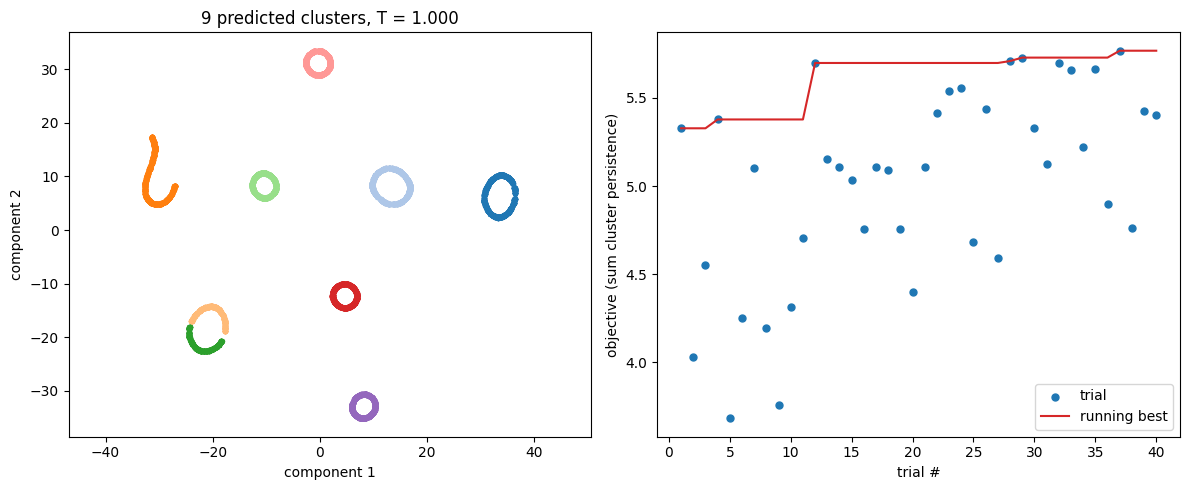

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sf.plot_embedding(result.embedding, result.labels, ax=axes[0])
axes[0].set_title(
    f'{result.n_clusters} predicted clusters, '
    f'T = {result.trustworthiness:.3f}'
)
sf.plot_optuna_history(result.search.study, ax=axes[1])
plt.tight_layout()
plt.show()

### 3D scatter, coloured by predicted labelFlip the same 3D chain but colour points by HDBSCAN's predictioninstead of the ground-truth torus index. Where a torus was splitinto two arcs, you'll see two colours on the same torus.

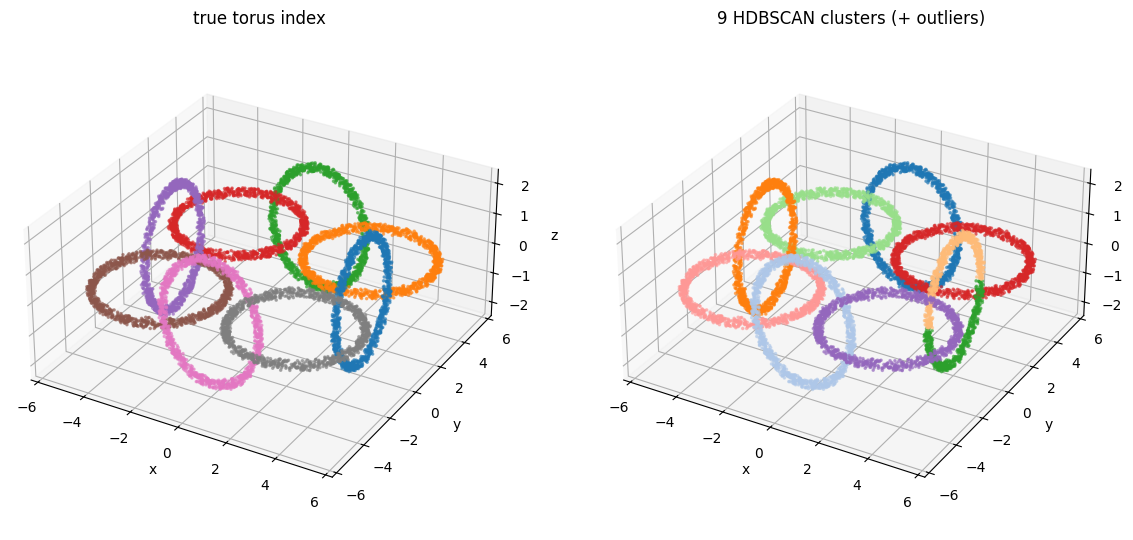

In [7]:
import matplotlib.colors as mcolors

fig = plt.figure(figsize=(12, 5.5))
ax_true = fig.add_subplot(121, projection='3d')
_scatter_chain(ax_true, X, y_true, 'true torus index')

ax_pred = fig.add_subplot(122, projection='3d')
cmap = plt.get_cmap('tab20')
uniq = sorted(set(result.labels.tolist()))
for lbl in uniq:
    mask = result.labels == lbl
    colour = 'lightgrey' if lbl == -1 else cmap(uniq.index(lbl) % 20)
    ax_pred.scatter(
        X[mask, 0], X[mask, 1], X[mask, 2],
        s=2.5, color=colour, alpha=0.55,
    )
ax_pred.set_xlabel('x'); ax_pred.set_ylabel('y'); ax_pred.set_zlabel('z')
ax_pred.set_title(f'{result.n_clusters} HDBSCAN clusters (+ outliers)')
ax_pred.set_box_aspect((1, 1, 0.5))
plt.tight_layout()
plt.show()

### Trustworthiness curve$T(k)$ measures how well local neighbourhoods are preserved from 3Dinto 2D. The paper's heuristic is $T(k_\text{neighbors}) > 0.9$.

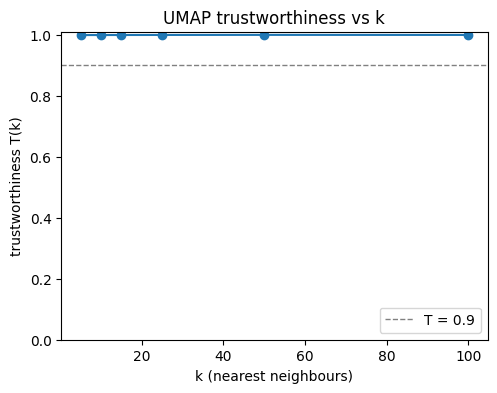

In [8]:
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
scores = sf.trustworthiness_curve(
    X_std, result.embedding, k_values=(5, 10, 15, 25, 50, 100),
)
fig, ax = plt.subplots(figsize=(5.5, 4.0))
sf.plot_trustworthiness_curve(scores, ax=ax, threshold=0.9)
ax.set_title('UMAP trustworthiness vs k')
plt.show()

## 4. Compare dimensionality-reduction methodsThe same 3D chain, embedded three different ways. PCA flattens thechain into its 2D shadow; t-SNE and UMAP try to preserve localtopology and end up unrolling the chain into visible loops.

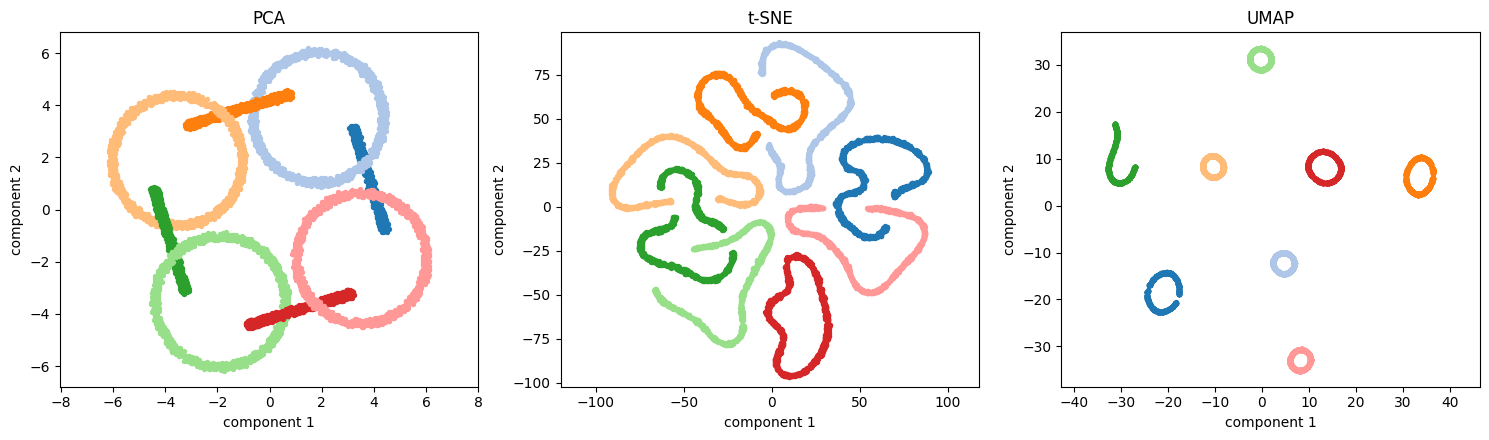

In [9]:
emb_pca = sf.run_pca(X)
emb_tsne = sf.run_tsne(X, n_iter=1000)
emb_umap = result.embedding
fig, _ = sf.plot_embedding_comparison(
    {'PCA': emb_pca, 't-SNE': emb_tsne, 'UMAP': emb_umap},
    y_true,
    figsize=(15, 4.5),
)
plt.show()

## 5. Two-run workflow (optional)The paper re-runs the pipeline on each top-level component separately.`starfold` does not bake this in; you filter the labels and call`fit` again on the subset:```pythonmask = result.labels == 0sub_result = pipeline.fit(X[mask])```Nothing about that is domain-specific -- the same pattern works forany dataset where you want to drill into a sub-cluster.